

# Part 2. Lifetime exposure

Functions from dem4cli for:

- GMT mapping : this is done year-to-year by matching smoothed GMT timeseries of your original simulation with target stylized GMT timeseries
- Land fraction exposed / average exceedances per year: Note - If your data is binary you will get the annual fraction of land exposed, but if it is not binary you will get the area-weighted average number of exceedances
- Lifetime exposure : per region/country, birthyear and GMT stylized pathways

To do / issues:
- add example smoothing da
- add back 'raw' RCP in le and lfe output if you pick to smooth the data? 
- region_names if subnational make them a bit more helpful! latin names not the acronyms

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('../..') # location of dem4cli package
#import demographics4climate as dem4cli # to call them as dem4cli.function 
from dem4cli import * # to call fxns directly


In [2]:
flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [3]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]
bbox_indiaws = [ 2.00, 35.00, 66.00, 100.00 ]

## 0) Population preprocessing

See part 1 for more details: load and preprocess all demographic data (population, cohort sizes, life expectancy)

In [4]:
d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    #bbox = bbox_europe,                        # could use bbox europe!!
    bbox = bbox_indiaws,

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

    
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

load_country_metadata took 0.42 s
load_unwpp_lifeexpectancy took 26.65 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 27.49 s
interpolate_cohortsize_countries took 0.02 s
opening compass - historical
opening compass - ssp2
load_population took 4.92 s
load_countrymask took 3.41 s
preprocess_all_country_data took 62.95 s


In [5]:
da_life_expectancy = (
    df_life_expectancy_5
    .to_xarray()
    .to_array('country')
    .rename({'Year': 'birth_year'})
    .astype(float)
)

In [6]:
df_life_expectancy_5

Country,Afghanistan,Bangladesh,Bhutan,China,India,Indonesia,Malaysia,Maldives,Myanmar,Nepal,Pakistan,Sri Lanka,Thailand
Year,,,,,,,,,,,,,
1950,54.7051,64.3785,57.9877,63.3719,64.9698,64.4966,66.4392,63.9401,62.6148,62.5044,62.6678,70.9775,64.0547
1951,54.9914,64.5367,58.0507,63.7418,65.1229,64.8597,66.9031,63.8358,62.9,62.4709,63.1308,71.3957,64.265
1952,55.3287,65.1587,58.1325,64.1075,65.192,65.2115,67.3864,63.7576,63.2916,62.495,63.5415,71.7427,64.4666
1953,55.6465,65.3259,58.2343,64.3401,65.3613,65.232,67.9438,63.7143,63.649,62.5481,63.9462,72.1706,64.6241
1954,55.9651,65.6375,58.3607,59.6083,65.6637,65.7349,68.507,63.6957,63.8958,62.719,64.333,72.5638,64.9301
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,82.9225,81.2563,85.5551,80.6474,78.9437,83.6094,88.1359,76.2366,78.775,78.0595,84.4865,83.8029
2022,76.441,83.1252,81.4446,85.748,80.8202,79.0574,83.7631,88.3445,76.3769,78.9434,78.1174,84.6453,83.9901
2023,76.5566,83.3198,81.6378,85.9295,80.9699,79.1701,83.9184,88.5411,76.5151,79.1097,78.1822,84.8139,84.1884


## 1) Load GMT stylized trajs

Load stylized GMT trajectories to emulate with the GMT-remapping. 

Using the options : 
- extension past 2100  with 10yrtrend (also available: 10yrmean, lastyear)
- Smoothing of first decades (OS and noOS currently not smoothed). Also available: no smoothing



In [7]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

load_GMT took 9.77 s


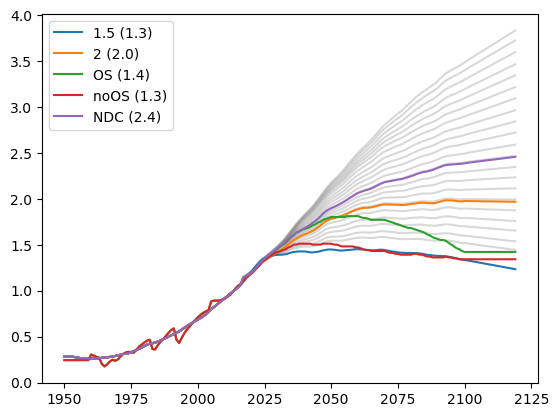

In [8]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

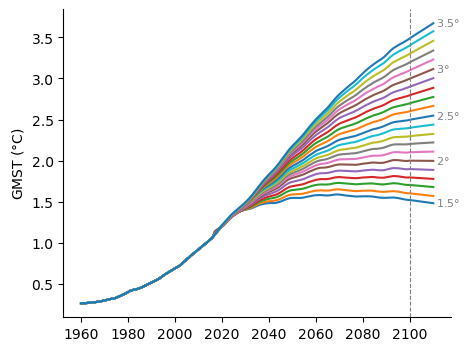

In [9]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

## 2) Load climate data and GMT-mapping recipe

Equivalent of old load_isimip() function. Loads in metadata with remapping recipe based on each target trajectory, linked to each original simulation

You can account for re-baselining GMTs to a different baseline (e.g. a bias-adjustment period)



In [10]:
df_gmst = pd.read_csv(os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'))
print(df_gmst['experiment_id'].unique())
print(df_gmst['source_id'].unique())
df_gmst

['historical' 'ssp126' 'ssp245' 'ssp370' 'ssp585']
['ACCESS-CM2' 'CNRM-ESM2-1' 'CanESM5' 'EC-Earth3' 'MPI-ESM1-2-HR'
 'MRI-ESM2-0']


,Unnamed: 0,year,experiment_id,source_id,tas
0,0,1850.0,historical,ACCESS-CM2,287.007494
1,1,1850.0,historical,CNRM-ESM2-1,286.900465
2,2,1850.0,historical,CanESM5,286.806542
3,3,1850.0,historical,EC-Earth3,287.029662
4,4,1850.0,historical,MPI-ESM1-2-HR,287.064616
...,...,...,...,...,...
7525,7525,2100.0,ssp585,CNRM-ESM2-1,292.475368
7526,7526,2100.0,ssp585,CanESM5,294.452385
7527,7527,2100.0,ssp585,EC-Earth3,293.272894
7528,7528,2100.0,ssp585,MPI-ESM1-2-HR,291.375668


In [11]:
gmt_anomaly_correction = calc_gmt_anomaly_correction(
    filepath_gmst_obs=os.path.join(data_dir, 'gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'),
    col='ERA5',
    gmt_anomaly_baseline_period=(1985,2014),)

gmt_anomaly_correction

# since the climate data is bias-adjusted to 1985-2014 rebaseline everything to this 

0.7432

In [12]:
# We will run the load_climate_data function with these arguments:

data_source = 'ISIMIP'
project_phase = 'ISIMIP2B'
#GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
GCMs = ['ACCESS-CM2']
#scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
scenarios = ['ssp126', 'ssp245']
extremes = ["heatwavedarea", "cropfailedarea"] # e.g. "FWI95d", "heatwavedarea"
IMs = {f"{extremes[0]}": ['hwmid99'], f"{extremes[1]}": ['GEPIC', 'LPJmL']}
GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS]
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv')
year_start=1950
year_end = 2119
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74
rolling_window=21
min_periods=11
max_diff_valid=.2

# Should this information also be declared here???
#data_source = "ISIMIP"
#project_phase = "isimip2b"
##extreme = "heatwavedarea"
#model = "hwmid99"
#gcm = "hadgem2-es"
#scenarios = ["rcp26", "rcp60"]

In [13]:
d_climate_data_meta = load_climate_data(
    data_source = data_source,
    project_phase = project_phase,
    extremes = extremes,                   # e.g. "FWI95d"
    gcm_names = GCMs,
    impact_model_names = IMs,             
    df_GMT_strj = df_GMT_strj ,                # stylized trajectories
    scenarios = scenarios,
    GMT_extra_trajectories = GMT_extra_trajectories,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    filepath_model_gmst = filepath_model_gmst,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for heatwavedarea
Processing for hwmid99
Processing for cropfailedarea
Processing for GEPIC
Processing for LPJmL


In [14]:
print(d_climate_data_meta[1])

{'data_source': 'ISIMIP', 'project_phase': 'ISIMIP2B', 'extreme': 'heatwavedarea', 'impact_model': 'hwmid99', 'gcm': 'ACCESS-CM2', 'scenario': 'ssp126', 'GMT':            tas
1950  0.385547
1951  0.393164
1952  0.393677
1953  0.379471
1954  0.362028
...        ...
2115  2.769605
2116  2.769605
2117  2.769605
2118  2.769605
2119  2.769605

[170 rows x 1 columns], 'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]), 'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]), 'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
       [ 23,  23,  23, ...,  23,  23,  23],
       [ 23,  23,  23, ...,  23,  23,  23],
       ...,
       [ 69,  72,  75, ..., 149, 149, 149],
       [ 69,  71,  75, ..., 149, 149, 149],
       [ 69,  71,  75, ..., 149, 149, 149]]), 'GMT_15_maxdiff': 0.05735471051576235, 'GMT_15_valid': True, 'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
 

In [15]:
print(d_climate_data_meta.keys())
for key, item in d_climate_data_meta.items():
    print(f"Entry {key} has keys: {list(item.keys())}")
    print(f"  Impact model for {key}: {item['impact_model']}")
d_climate_data_meta

dict_keys([1, 2, 3, 4, 5, 6])
Entry 1 has keys: ['data_source', 'project_phase', 'extreme', 'impact_model', 'gcm', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
  Impact model for 1: hwmid99
Entry 2 has keys: ['data_source', 'project_phase', 'extreme', 'impact_model', 'gcm', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
  Impact model for 2: hwmid99
Entry 3 has keys: ['data_source', 'project_phase

{1: {'data_source': 'ISIMIP',
  'project_phase': 'ISIMIP2B',
  'extreme': 'heatwavedarea',
  'impact_model': 'hwmid99',
  'gcm': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.05735471051576235,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23,

In [16]:
df_mapping = pd.DataFrame(data=d_climate_data_meta[1]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
df_mapping

# what index of the simulation is mapped, for all GMT levels, to each year in the scenario-GCM combination corresponding to the first dictionary entry

,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1951,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1952,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1953,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1954,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,69,72,75,78,81,84,87,91,95,100,...,130,149,149,149,149,149,149,149,149,149
2116,69,72,75,78,81,84,87,92,95,100,...,131,149,149,149,149,149,149,149,149,149
2117,69,72,75,78,81,84,87,92,95,100,...,132,149,149,149,149,149,149,149,149,149
2118,69,71,75,78,81,84,87,92,95,100,...,133,149,149,149,149,149,149,149,149,149


KeyError: 7

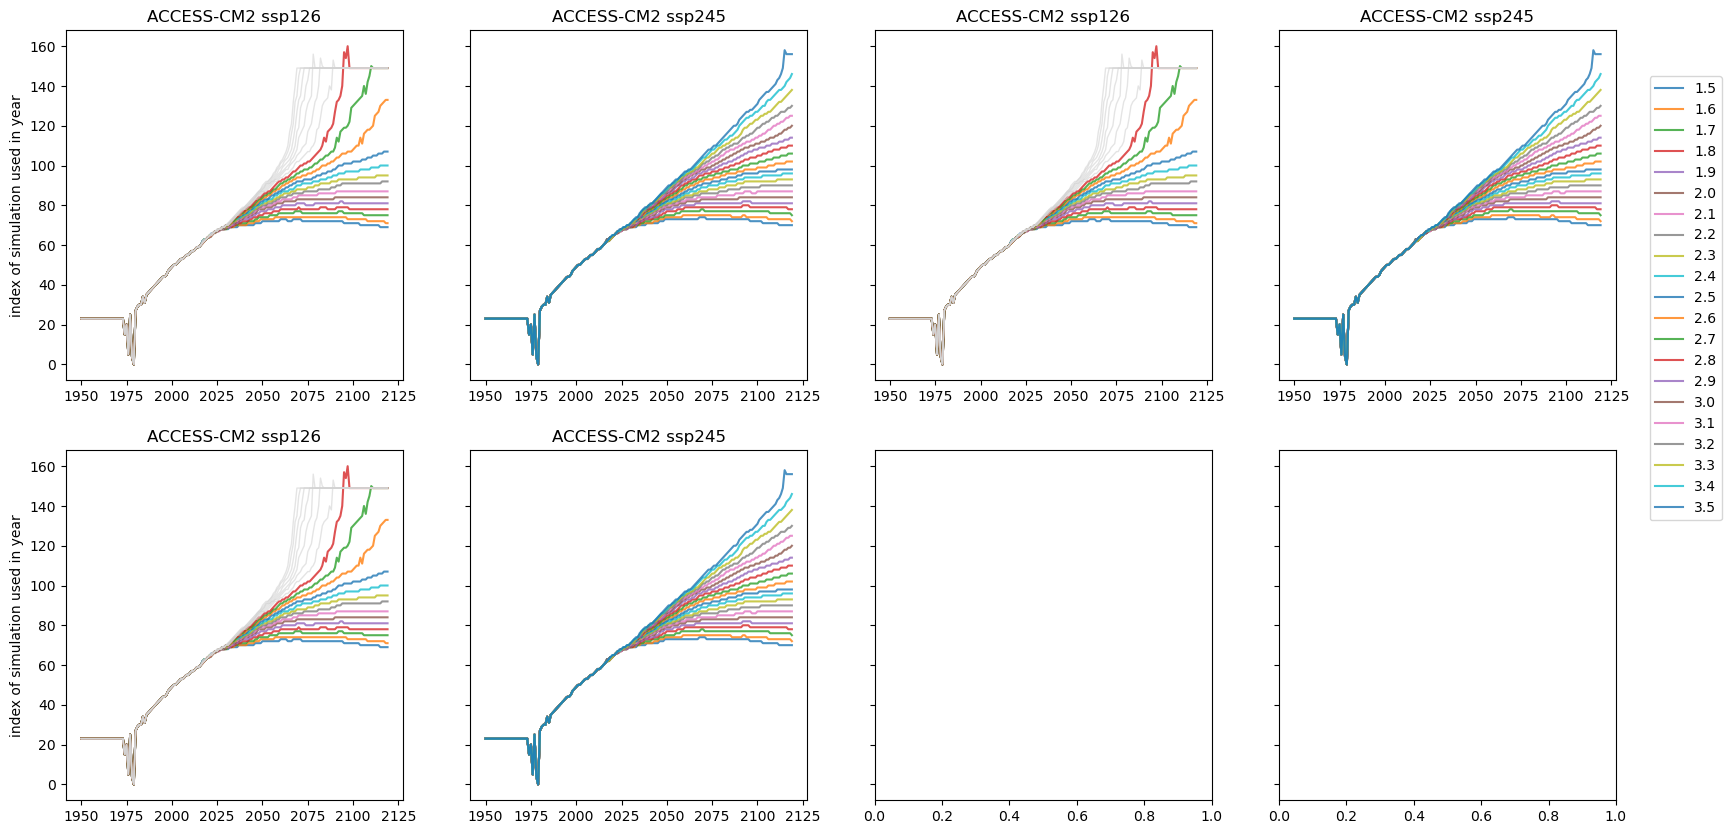

In [17]:
fig, axes = plt.subplots(2,4,figsize=(20,10),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['gcm']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4:
        ax.legend(loc=(1.1,-.4))

    # visualize the remapping

    # gray = not valid 

## 3) Land fraction exposed

Note! If your data is BINARY this is land fraction exposed. 

If your data is not binary but is N OF EXCEEDANCES PER YEAR, then you will get the area-weighted average n of exceedances per spatial unit

In [65]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    gcm = d_climate_data_meta[i]['gcm']
    print(i, gcm, scenario)

# get the names / experiments of each element of the dict

# for each dict entry you have remapping recipe for each valid target trajectory 

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp126
4 ACCESS-CM2 ssp245
5 ACCESS-CM2 ssp126
6 ACCESS-CM2 ssp245


In [66]:
d_meta_subset = dict(list(d_climate_data_meta.items())[0:3])
d_meta_subset

# test just for a subset of the simulations (faster to run)

{1: {'data_source': 'ISIMIP',
  'project_phase': 'ISIMIP2B',
  'extreme': 'heatwavedarea',
  'impact_model': 'hwmid99',
  'gcm': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.05735471051576235,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23,

In [67]:
for key, item in d_meta_subset.items():
    print(f"Entry {key} has keys: {list(item.keys())}")

Entry 1 has keys: ['data_source', 'project_phase', 'extreme', 'impact_model', 'gcm', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
Entry 2 has keys: ['data_source', 'project_phase', 'extreme', 'impact_model', 'gcm', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
Entry 3 has keys: ['data_source', 'project_phase', 'extreme', 'impact_model', 'gcm', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_vali

In [68]:
for i in list(d_meta_subset.keys()):
    scenario = d_meta_subset[i]['scenario']
    gcm = d_meta_subset[i]['gcm']
    im = d_meta_subset[i]['impact_model']
    extr = d_meta_subset[i]['extreme']
    print(i, gcm, scenario, im, extr)

1 ACCESS-CM2 ssp126 hwmid99 heatwavedarea
2 ACCESS-CM2 ssp245 hwmid99 heatwavedarea
3 ACCESS-CM2 ssp126 GEPIC cropfailedarea


In [69]:
# Temporary: to move elsewhere

#data_source = "ISIMIP"
#project_phase = "isimip2b"
#extreme = "heatwavedarea"
#impact_model = "hwmid99"
gcm = "gfdl-esm2m"
scenarios = ["rcp26", "rcp60", "rcp26"]

#climatedata_dir = '/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data'


In [70]:
# Temporary hard-coding
# RE-DO THIS BETTER!

#i = 1
#for scen in scenarios:
#    d_meta_subset[i]['gcm'] = gcm   
#    d_meta_subset[i]['scenario'] = scen
#    i += 1

for i in list(d_meta_subset.keys()):
    d_meta_subset[i]['gcm'] = gcm
    d_meta_subset[i]['scenario'] = scenarios[i-1]
    scen = d_meta_subset[i]['scenario']
    mod = d_meta_subset[i]['gcm']
    i_m = d_meta_subset[i]['impact_model']
    print(i, mod, scen, i_m)

1 gfdl-esm2m rcp26 hwmid99
2 gfdl-esm2m rcp60 hwmid99
3 gfdl-esm2m rcp26 GEPIC


In [71]:
print(extremes)
print(IMs[extremes[0]])
#print(IMs['heatwavedarea'][0])
print(gcm)

['heatwavedarea', 'cropfailedarea']
['hwmid99']
gfdl-esm2m


In [72]:
filepath_hist = glob.glob(os.path.join(climatedata_dir, data_source.lower(), project_phase.lower(), extremes[0], IMs[extremes[0]][0].lower(), f'{IMs[extremes[0]][0].lower()}_{gcm}_historical*1861_2005.nc4'))[0]
filepath_rcp = glob.glob(os.path.join(climatedata_dir, data_source.lower(), project_phase.lower(), extremes[0], IMs[extremes[0]][0].lower(), f'{IMs[extremes[0]][0].lower()}_{gcm}_{scenarios[0]}*2006_2099.nc4'))[0]
print(filepath_hist)
print(filepath_rcp)

/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_rcp26_heatwavedarea_global_annual_landarea_2006_2099.nc4


In [73]:
#GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
#scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
# GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']

ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    d_meta_subset, # replace with d_climate_data_meta to run all data
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    GMT_labels = df_GMT_strj.columns,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    year_start=1950,
    year_end=2119,
    bbox=bbox_indiaws,
    weights=None,
    areaweighted=True,
    convert_to_binary=False,            # if your data array is number of exceedances per year (not binary) you will get area-weighted average number of exceedances by default
                                        # if you set this to True your data is turned binary and you can get fraction of land area exposed to at least 1 day
    convert_to_binary_threshold=0,      # here you can change the threshold to e.g. get the fraction of land area exposed to at least X days 
    smoothing_window=21                 # window to smooth also the impact data, get only forced signal not internal variability
                                        # turn this to None for default configuration
)


# note: calling this LFE can be misleading if your data is not binary!

                         🟠 Remapping Simulation 1 of 3 🟠

Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_rcp26_heatwavedarea_global_annual_landarea_2006_2099.nc4
load_climate_data_array took 0.09 s
Computing land fraction exposed (LFE) for RCP 

Computing land fraction exposed (LFE) for 15              

Computing land fraction exposed (LFE) for 20              

Computing land fraction exposed (LFE) for NDC             

Computing land fraction exposed (LFE) for OS              

Computing land fraction exposed (LFE) for noOS            

Computing land fraction exposed (LFE) for strj            

                         🟠 Remapping Simulation 2 of 3 🟠

Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/

In [74]:
rename_dict = {
    #i: " ".join(["hadgem2-es (h-c)", "rcp60 (hc)"])
    i: f"{gcm} {d_meta_subset[i]['scenario']}"
    for i in d_meta_subset.keys()
}

rename_dict

{1: 'gfdl-esm2m rcp26', 2: 'gfdl-esm2m rcp60', 3: 'gfdl-esm2m rcp26'}

In [75]:
print(ds_lfe_perregion_perrun.dims)

Frozen({'run': 3, 'region': 6, 'time_ind': 170, 'GMT': 21})


In [76]:
print(ds_lfe_perregion_perrun.GMT)
print(ds_lfe_perregion_perrun.region)
print(region_names)
ds_lfe_perregion_perrun

<xarray.DataArray 'GMT' (GMT: 21)>
array([1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8,
       2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5])
Coordinates:
  * GMT      (GMT) float64 1.5 1.6 1.7 1.8 1.9 2.0 ... 3.0 3.1 3.2 3.3 3.4 3.5
<xarray.DataArray 'region' (region: 6)>
array([0, 1, 2, 3, 4, 5])
Coordinates:
  * region   (region) int64 0 1 2 3 4 5
['South Asia' 'East Asia & Pacific' 'Low income' 'Lower middle income'
 'Upper middle income' 'World']


<xarray.Dataset>
Dimensions:                          (run: 3, region: 6, time_ind: 170, GMT: 21)
Coordinates:
  * run                              (run) int64 1 2 3
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
  * GMT                              (GMT) float64 1.5 1.6 1.7 ... 3.3 3.4 3.5
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 0.02181 ...
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 0.006837...
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 0.006837...
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 0.006837...
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 0.006837...
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 0.006837...
    landfrac_peryear_perregion_strj  (run, region, time_ind, GMT) float64 0.0...

In [ ]:
#selected_runs = [run for run, info in d_meta_subset.items() if info['extreme'] == 'heatwavedarea']
#selected_runs

[1, 2]

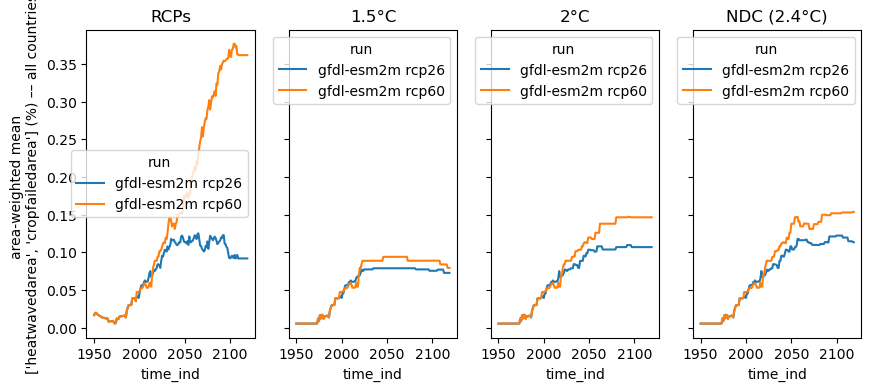

In [80]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

ds_lfe_perregion_perrun.sel(run=selected_runs,region=5)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0])
ds_lfe_perregion_perrun.sel(run=selected_runs,region=5)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1])
ds_lfe_perregion_perrun.sel(run=selected_runs,region=5)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2])
ds_lfe_perregion_perrun.sel(run=selected_runs,region=5)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCPs', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xticklabels([int(t + year_start) for t in ax.get_xticks()])

axes[0].set_ylabel(f'area-weighted mean \n{extremes} (%) –– all countries');


## 4) Lifetime exposure 

Lifetime exposure per run, and aggregated across runs ("multi-model") for original RCP and for target trajectories after remapping. 

also outputs region names and population-weighted average life-expectancy per region (should this be weighted by cohort aged 0 or total population?? - Ask Emma)



In [81]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names, da_life_expectancy_perregion = calc_lifetime_exposure(
   d_meta_subset,
   df_countries, 
   countries_regions, 
   countries_mask, 
   climatedata_dir,
   da_population, 
   df_life_expectancy_5,
   da_cohort_size,
   GMT_labels=df_GMT_strj.columns , 
   GMT_extra_trajectories_names=GMT_extra_trajectories_names,
   start_birthyear=1950,
   end_birthyear=2025,
   year_start=1950,
   year_end=2119,
   bbox=bbox_indiaws,
   smoothing_window=21   
    )



                         🟠 Remapping Simulation 1 of 3 🟠

Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_rcp26_heatwavedarea_global_annual_landarea_2006_2099.nc4
load_climate_data_array took 0.11 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing life

In [82]:
# For each country and model run, this dataset gives the cumulated number of years a typical person from each birth cohort is or will be affected by a heatwave.

ds_le_percountry_perrun

<xarray.Dataset>
Dimensions:                    (run: 3, country: 13, birth_year: 76, GMT: 21)
Coordinates:
  * run                        (run) int64 1 2 3
  * country                    (country) object 'Afghanistan' ... 'Thailand'
  * birth_year                 (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                        (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_percountry_perrun_RCP   (run, country, birth_year) float64 3.578 ... 0...
    le_percountry_perrun_15    (run, country, birth_year) float64 4.282 ... 0...
    le_percountry_perrun_20    (run, country, birth_year) float64 4.282 ... 0...
    le_percountry_perrun_NDC   (run, country, birth_year) float64 4.282 ... 0...
    le_percountry_perrun_OS    (run, country, birth_year) float64 4.389 ... 0...
    le_percountry_perrun_noOS  (run, country, birth_year) float64 4.389 ... 0...
    le_percountry_perrun_strj  (run, country, birth_year, GMT) float64 4.282 ...

In [83]:
ds_le_perregion_perrun

<xarray.Dataset>
Dimensions:                   (run: 3, region: 6, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2 3
  * region                    (region) int64 0 1 2 3 4 5
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.388 ... 3.908
    le_perregion_perrun_15    (run, region, birth_year) float64 1.244 ... 2.689
    le_perregion_perrun_20    (run, region, birth_year) float64 1.244 ... 3.183
    le_perregion_perrun_NDC   (run, region, birth_year) float64 1.244 ... 3.645
    le_perregion_perrun_OS    (run, region, birth_year) float64 1.233 ... 2.983
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.233 ... 2.876
    le_perregion_perrun_strj  (run, region, birth_year, GMT) float64 1.244 .....

In [84]:
region_names

array(['South Asia', 'East Asia & Pacific', 'Low income',
       'Lower middle income', 'Upper middle income', 'World'],
      dtype=object)

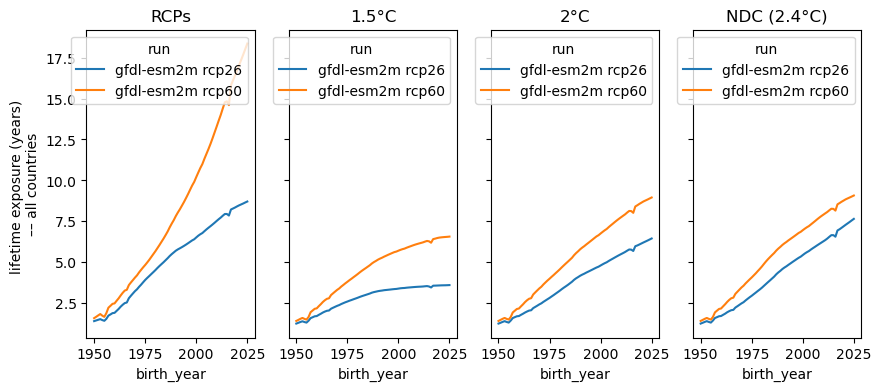

In [85]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_le_perregion_perrun.sel(run=selected_runs,region=5)['le_perregion_perrun_RCP'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[0])
(ds_le_perregion_perrun.sel(run=selected_runs,region=5)['le_perregion_perrun_15'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[1])
(ds_le_perregion_perrun.sel(run=selected_runs,region=5)['le_perregion_perrun_20'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[2])
(ds_le_perregion_perrun.sel(run=selected_runs,region=5)['le_perregion_perrun_NDC'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCPs', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])

axes[0].set_ylabel(f'lifetime exposure (years) \n–– all countries');


# TODO: run for all simulations and see! 

## 5) aggregation function

Median, mean and spread across 'runs' i.e. across remapped / synthetic trajectories

In [92]:
#  area-weighted average (i.e. land fraction exposed if binary)


ds_lfe_perregion_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_perregion_perrun,
    GMT_extra_trajectories_names,
    )



Computing the MMM and stats for each region


In [93]:
# lifetime exposure 

ds_le_perregion_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each region


In [94]:

ds_lfe_percountry_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_percountry_perrun,
    GMT_extra_trajectories_names,
    )


Computing the MMM and stats for each country


In [95]:
ds_le_percountry_mmm = calc_lifetime_exposure_mmm(
    ds_le_percountry_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each country


## 6) Plots

In [96]:
region_names

# Note that World = all countries/area included in your bounding box 

array(['South Asia', 'East Asia & Pacific', 'Low income',
       'Lower middle income', 'Upper middle income', 'World'],
      dtype=object)

Text(0.5, 1.0, 'all countries')

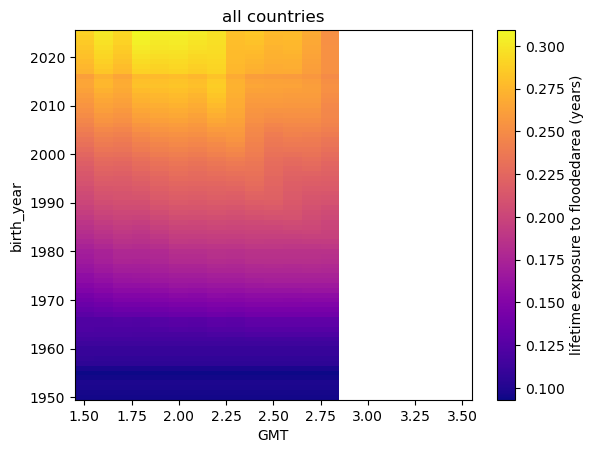

In [97]:
# plot heatmap from median of remapped trajectories (units:years exposed)

(ds_le_perregion_mmm['median_strj']).sel(region=5).plot(
    cbar_kwargs={'label': f"lifetime exposure to {extremes} (years)"},
    cmap='plasma'
    )

plt.title('all countries')


Text(0.5, 1.0, 'all countries')

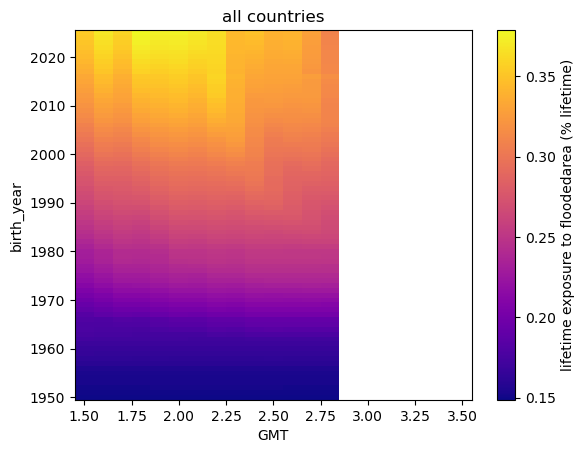

In [98]:
# plot % lifetime exposed 

(((ds_le_perregion_mmm['median_strj']) / da_life_expectancy_perregion)*100).sel(region=5).plot(
    cbar_kwargs={'label': f"lifetime exposure to {extremes} (% lifetime)"},
    cmap='plasma'
    )

plt.title('all countries')



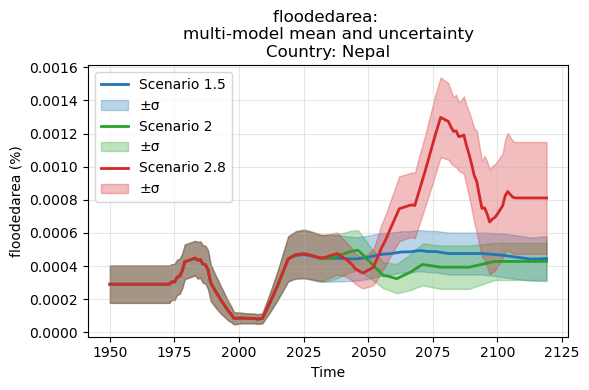

In [99]:
# timeseries area-weighted average


# === Parameters ===
country_name = 'Nepal'  # <-- change the country here
year_range = np.arange(1950, 1950+len(ds_lfe_percountry_mmm.time_ind))  # x-axis: birth years

# === Define the scenarios to plot ===
GMTs = 1.5, 2, 2.8
colors = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'}

# === Create the figure ===
plt.figure(figsize=(6,4))

for i,scen in enumerate(GMTs):
    # Extract multi-model mean and standard deviation for this scenario
    mmm = ds_lfe_percountry_mmm[f'mmm_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean() # this is mmm_strj smoothed with .rolling(time_ind=10, center=True, min_periods=1).mean()
    std = ds_lfe_percountry_mmm[f'std_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean()
    
    # Plot the mean
    plt.plot(
        year_range, 
        mmm, 
        label=f'Scenario {scen}', 
        color=colors[i],
        lw=2
    )
    
    # Plot the uncertainty range (±σ/2)
    plt.fill_between(
        year_range,
        mmm - std,
        mmm + std ,
        alpha=0.3,
        label=rf'±σ',
        color=colors[i],
        lw=1
    )

# === Customize the plot ===
plt.title(f"{extremes}: \nmulti-model mean and uncertainty\nCountry: {country_name}")
plt.xlabel("Time")
plt.ylabel(f"{extremes} (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



0.004446706748325368 0.38487677497166445
0.010141853959519222 1.197824333872553
0.012664799772773312 1.154324483810866


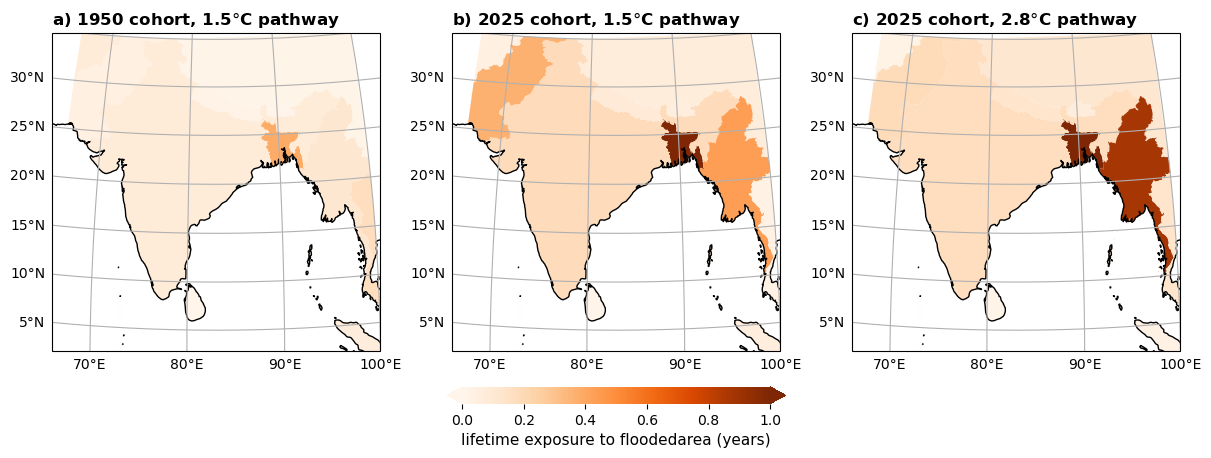

In [101]:
# map : South Asia, country level results



# -------------------- Parameters -------------------- #
GMTs = [1.5, 1.5, 2.8]
birth_years = [1950,2025,2025]
titles = ['a)', 'b)', 'c)']

use_log_scale = False

vmin=0
vmax=1

cmap = plt.cm.Oranges # or OrRd

# -------------------- Projections ---------- #

central_lon, central_lat = 83, 18.5
extent = [66, 100, 2, 35]

proj = ccrs.Orthographic(central_lon, central_lat)

# -------------------- Plot -------------------- #

fig, axes = plt.subplots(1,3, figsize=(12,8),subplot_kw={'projection': proj},  layout='constrained')


for ax, birth_year, GMT, title in zip(axes.flatten(), birth_years, GMTs, titles):


    # -------------------- Extract values from ds_le_percountry -------------------- #
    # Multi-model mean for the selected scenario
    le_mean = ds_le_percountry_mmm[f'mmm_strj'].sel(birth_year=birth_year, GMT=GMT) # for % lfietime  / da_life_expectancy * 100

    # Convert to DataFrame
    df_values = le_mean.to_dataframe(name='mean_val').reset_index()

    # -------------------- Merge with country borders -------------------- #
    gdf_plot = gdf_country_borders.reset_index().merge(
        df_values, left_on='name', right_on='country', how='left'
    )

    gdf_plot.to_crs(proj).plot(
    ax=ax,
    column='mean_val',
    cmap=cmap,
    legend=False,
    legend_kwds={'shrink': 0.5},
    missing_kwds={'color': 'lightgrey'},
    vmin=vmin,vmax=vmax
    )

    ax.set_title(title+f' {birth_year} cohort, {GMT}$\degree$C pathway', loc='left', fontweight='bold')
    ax.set_extent(extent)
    gl = ax.gridlines( draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False
    ax.coastlines(resolution='50m')

    print(gdf_plot['mean_val'].min(), gdf_plot['mean_val'].max())

# colorbar 
foo = ax.collections[0]
cbar_lab = f'lifetime exposure to {extremes} (years)'
cbar = fig.colorbar(foo, extend='both', ax=axes[0:3], location='bottom',shrink=0.3, fraction=0.08, pad=0.02)
cbar.set_label(label=cbar_lab,size=11)
cbar.outline.set_edgecolor('none')
